# Assignment 1: Neural Network from scratch

In this assignment, you will focus on building the foundational structure for a learning algorithm.
You are required to build a logistic regression classifier from scratch to classify MNIST digits into 2 categories: less than or equal to 5 and greater than 5, by following these steps:

- Initialize the necessary parameters.
- Implement the cost function and compute its gradient.
- Apply an optimization technique (such as gradient descent) to minimize the cost.

Make sure to gather these components—initialization, cost calculation, and optimization—into a cohesive main model function, executed in the correct sequence.

**Instructions:**
- Do not use loops (for/while) in your code, unless explicitly asked to do so.

In [ ]:
%pip install torch
%pip install torchvision
%pip install numpy

   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   - -------------------------------------- 3.1/124.1 MB 18.5 MB/s eta 0:00:07
   - -------------------------------------- 6.0/124.1 MB 16.3 MB/s eta 0:00:08
   -- ------------------------------------- 8.7/124.1 MB 15.0 MB/s eta 0:00:08
   --- ------------------------------------ 10.5/124.1 MB 13.5 MB/s eta 0:00:09
   --- ------------------------------------ 11.8/124.1 MB 12.0 MB/s eta 0:00:10
   ---- ----------------------------------- 13.4/124.1 MB 11.2 MB/s eta 0:00:10
   ---- ----------------------------------- 15.2/124.1 MB 10.8 MB/s eta 0:00:11
   ----- ---------------------------------- 17.3/124.1 MB 10.7 MB/s eta 0:00:10
   ------ --------------------------------- 19.7/124.1 MB 10.8 MB/s eta 0:00:10
   ------- -------------------------------- 22.5/124.1 MB 11.0 MB/s eta 0:00:10
   ------- -------------------------------- 24.4/124.1 MB 10.9 MB/s eta 0:00:10
   -------- ------------------------------- 26.0/124

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 21.0 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ----------------------- ---------------- 4.2/7.2 MB 20.2 MB/s eta 0:00:01
   ---------------------------------- ----- 6.3/7.2 MB 15.1 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 11.7 MB/s  0:00:00

   ---------------------------------------- 0/2 [pillow]
   ---------------------------------------- 0/2 [pillow]
   ---------------------------------------- 0/2 [pillow]
   ---------------------------------------- 0/2 [pillow]
   -------------------- ------------------- 1/2 [torchvision]
   -------------------- ------------------- 1/2 [torchvision]
   -------------------- ------------------- 1/2 [torchvision]
   -------------------- ------------------- 1/2 [torchvision]
   -------------------- ------------------- 1/2 [torchvision]
   ------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   -------------------------------- ------- 6.8/8.4 MB 36.6 MB/s eta 0:00:01
   ---------------------------------------- 8.4/8.4 MB 27.7 MB/s  0:00:00
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   --- ------------------------------------ 3.1/37.4 MB 16.8 MB/s eta 0:00:03
   ------ --------------------------------- 6.0/37.4 MB 15.1 MB/s eta 0:00:03
   -------- ------------------------------- 8.1/37.4 MB 13.5 MB/s eta 0:00:03
   ----------- ---------------------------- 10.5/37.4 MB 13.0 MB/s eta 0:00:03
   -------------- ------------------------- 13.1/37.4 MB 12.9 MB/s eta 0:00:02
   ----------------- ---------------------- 16.0/37.4 MB 13.1 MB/s eta 0:00:02
   ------------------- -------------------- 18.4/37.4 MB 12.9 MB/s eta 0:00:02
   ---------------------- ----------------- 20.7/37.4 MB 12.7 MB/s eta 0:00:02
   ------------------------ --------------- 23.1/37.4 MB 12.5 MB/s eta 0:00:02
  


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import torch
from torchvision import datasets, transforms
import numpy as np
import random

## Load packages

In [8]:
import torch
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
import numpy as np
import random

ImportError: DLL load failed while importing _fitpack: An Application Control policy has blocked this file.

# Setting the seed for reporducibility

### Don't modify this!

In [2]:
seed = 2026

np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

## Dataset description.

The MNIST (Modified National Institute of Standards and Technology) dataset is a well-known collection of handwritten digits commonly used for training and testing machine learning algorithms, particularly in the field of computer vision. It consists of 70,000 grayscale images of handwritten digits (0-9) in 28x28 pixel resolution.



## Loading the dataset

In [3]:
# Define the transformation to normalize the images to tensors
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Load the MNIST dataset (only training set, as we will split it ourselves)
mnist_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Convert images to numpy arrays and labels to numpy arrays
images = mnist_data.data.numpy()  # Shape: (60000, 28, 28)
labels = mnist_data.targets.numpy()  # Shape: (60000,)


# Split data into training, validation, and test sets
# We use 80% for training, 10% for validation, and 10% for testing
X_train, X_test, train_set_y, test_set_y = train_test_split(images, labels, test_size=0.2, random_state=2026)

# Verify the shapes of the resulting datasets
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (48000, 28, 28)
Test data shape: (12000, 28, 28)


# Transform Data (2.5 points)
Reshape the training and test data sets so that images of size (number of examples, num_px, num_px ) are flattened into single vectors of shape (number of examples, num_px * num_px).


In [ ]:
# Reshape the training and test examples

### START CODE HERE ###
train_set_x_flatten = X_train.reshape(X_train.shape[0], -1)
test_set_x_flatten = X_test.reshape(X_test.shape[0], -1)
### END CODE HERE ###

print ("train_set_x_flatten shape: " + str(train_set_x_flatten.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x_flatten shape: " + str(test_set_x_flatten.shape))
print ("test_set_y shape: " + str(test_set_y.shape))

train_set_x_flatten shape: (48000, 784)
train_set_y shape: (48000,)
test_set_x_flatten shape: (12000, 784)
test_set_y shape: (12000,)


## Let's normalize the dataset

In [5]:
train_set_x= (train_set_x_flatten/255.).T
test_set_x = (test_set_x_flatten/255.).T

# Modify the labels to binary

In [6]:
test_set_y = test_set_y >= 5
train_set_y = train_set_y >= 5

## General Architecture

**Mathematical expression of the algorithm**:

For one example $x^{(i)}$:

\begin{equation*}
z^{(i)} = w^T x^{(i)} + b \\
\hat{y}^{(i)} = a^{(i)} = sigmoid(z^{(i)}) \\
\mathcal{L}(a^{(i)}, y^{(i)})=-y^{(i)}\log(a^{(i)})-(1-y^{(i)})\log(1-a^{(i)})
\end{equation*}

The cost is then computed by summing over all training examples:

\begin{equation}
J = \frac{1}{m}\sum^m_{i=1}\mathcal{L}(a^{(i)},y^{(i)})
\end{equation}

**The goal** of this assignment is to:
- Initialise the parameters of the model
- Learn the model parameters by minimising the cost
- Used the learned parameters to make predictions (on the test set)
- Analyse the results and conclude

# Constructing the algorithm

The main steps for constructing a Neural Network are:
1. Define the model structure (such as number of input features)
2. Initialise the model's parameters
3. Loop:
- Calculate current loss (forward propagation)
- Calculate current gradient (backward propagation)
- Update parameters (gradient descent)

You often build 1-3 separately and integrate them into a single function called `model()`.

## Activation function (2.5 points)

**Task: Implement `sigmoid()`**. Recall, from above, you need to compute $sigmoid(w^Tx+b)$ to make predictions.

In [1]:
# GRADED FUNCTION: sigmoid

def sigmoid(z):
    """
    Compute the sigmoid of z

    Arguments:
    x -- A scalar or numpy array of any size.

    Return:
    s -- sigmoid(z)
    """

    ### START CODE HERE ###
    s = 1 / (1 + np.exp(-z))
    ### END CODE HERE ###

    return s

In [12]:
print ("sigmoid(0) = " + str(sigmoid(0)))
print ("sigmoid(1) = " + str(sigmoid(1)))
print ("sigmoid(-1) = " + str(sigmoid(-1)))

sigmoid(0) = 0.5
sigmoid(1) = 0.7310585786300049
sigmoid(-1) = 0.2689414213699951


#### **Expected output**:

\begin{align}
\\& sigmoid(0) = 0.5
\\& sigmoid(1) = 0.7310585786300049
\\& sigmoid(-1) = 0.2689414213699951
\end{align}

# Initializing parameters  (2.5 points)

**Task** Initialise the parameters. Below, you have to initialise `w` as a vector of `zeros`.

_Hint_: Look up [`np.zeros`](https://numpy.org/doc/2.1/reference/generated/numpy.zeros.html) in `Numpy` library's documentation if you don't know what numpy function to use.

In [16]:
# GRADED FUNCTION: initialize_with_zeros

def initialize_with_zeros(dim):
    """
    Create a vector of zeros with the appropriate shape for w and initialize b to 0.

    Argument:
    dim -- size of the w vector we want (ie. number of parameters in this case)

    Return:
    w -- initialized vector (hint: use dim)
    b -- initialized scalar (corresponds to the bias)
    """

    ### START CODE HERE ###
    w = np.zeros((dim, 1))
    b = 0
    ### END CODE HERE ###

    return w, b

In [17]:
dim = 2
w, b = initialize_with_zeros(dim)
print ("w = " + str(w))
print ("b = " + str(b))

w = [[0.]
 [0.]]
b = 0


#### **Expected output**:
<table style="width:15%">
    <tr>
        <td>  ** w **  </td>
        <td> [[ 0.]<br>[ 0.]] </td>
    </tr>
    <tr>
        <td>  ** b **  </td>
        <td> 0 </td>
    </tr>
</table>


# Forward and Backward propogation (30 points)

**Task:** Implement a function `propagate()` that computes the cost function and its gradient.

**Hints**:

Forward Propagation (10 points):
- Given input X
- Compute $A = \sigma(w^T X + b) = (a^{(0)}, a^{(1)}, ..., a^{(m-1)}, a^{(m)})$
- Calculate the cost function: $J = -\frac{1}{m}\sum_{i=1}^{m}y^{(i)}\log(a^{(i)})+(1-y^{(i)})\log(1-a^{(i)})$

Backward Propogation (20 points):
- Take the derivative of the cost function with respect W and b.


### Questions (0.5 pts):
Answer the following questions in descriptive terms, such as: num_pixels, num_samples, etc.

Note, simply replace the designated placeholders with your answer.

_Hint_: Make sure to properly define the dimensions as row or column vectors where appropriate, eg., (shape, 1) or (1, shape)

1. **The weights are of size (0.1 pts):** (num_pixels * num_pixels, 1)
2. **The bias is of size (0.1 pts):** 1
3. **X is of size (0.1 pts):** (num_pixels * num_pixels, num_samples)
4. **Y is of size (0.1 pts):** (1, num_samples)
5. **Gradient of the loss with respect to w is of size (0.05pts):** (num_pixels * num_pixels, 1)
6. **Gradient of the loss with respect to b is of size (0.05pts):** 1

In [ ]:
# GRADED FUNCTION: propagate

def propagate(w, b, X, Y):
    """
    Create the cost function and compute the gradient for the forward and back propagations explained above

    Arguments:
    w -- weights
    b -- bias
    X -- data
    Y -- true "label" vector (containing 0 if less than 5, 1 if greater or equal to 5)

    Return:
    cost -- negative log-likelihood cost for logistic regression
    dw -- gradient of the loss with respect to w
    db -- gradient of the loss with respect to b

    Tips:
    - Write your code step by step for the propagation
    """

    m = X.shape[1]

    # FORWARD PROPAGATION (FROM X TO COST) (10 pts)
    ### START CODE HERE ###
    A =  sigmoid(np.dot(w.T, X) + b)
    cost = -(1/m) * np.sum(Y * np.log(A) + (1 - Y) * np.log((1 - A)))
    ### END CODE HERE ###

    # BACKWARD PROPAGATION (TO FIND GRAD) (20 pts)
    ### START CODE HERE ###
    dw = 
    db =
    ### END CODE HERE ###

    assert(dw.shape == w.shape)
    assert(db.dtype == float)
    cost = np.squeeze(cost)
    assert(cost.shape == ())

    grads = {"dw": dw,
             "db": db}

    return grads, cost

In [12]:
w, b, X, Y = np.array([[0.5], [-0.5]]), 1, np.array([[3,1], [5,4]]), np.array([[0, 2]])
grads, cost = propagate(w, b, X, Y)
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print ("cost = " + str(cost))

dw = [[-0.06122967]
 [-1.99491866]]
db = -0.5612296656009272
cost = 1.0836120823700262


**Expected Output**:

<table style="width:50%">
    <tr>
        <td>  ** dw **  </td>
        <td> [[ -0.06122967]<br>[-1.99491866]]</td>
    </tr>
    <tr>
        <td>  ** db **  </td>
        <td> -0.5612296656009272 </td>
    </tr>
    <tr>
        <td>  ** cost **  </td>
        <td> 1.0836120823700262</td>
    </tr>

</table>

# Optimization (10 points)
- You have initialized your parameters.
- You are also able to compute a cost function and its gradient.
- Now, you want to update the parameters using gradient descent.

Write down the optimization function. The goal is to learn $w$ and $b$ by minimizing the cost function $J$. For a parameter $\theta$, the update rule is $ \theta = \theta - \alpha \text{ } d\theta$, where $\alpha$ is the learning rate.

In [13]:
# GRADED FUNCTION: optimize

def optimize(w, b, X, Y, num_iterations, learning_rate, print_cost = False):
    """
    This function optimizes w and b by running a gradient descent algorithm

    Arguments:
    w -- weights
    b -- bias
    X -- data
    Y -- true "label" vector (containing 0 if less than 5, 1 if greater or equal to 5)
    num_iterations -- number of iterations of the optimization loop
    learning_rate -- learning rate of the gradient descent update rule
    print_cost -- True to print the loss every 100 steps

    Returns:
    params -- dictionary containing the weights w and bias b
    grads -- dictionary containing the gradients of the weights and bias with respect to the cost function
    costs -- list of all the costs computed during the optimization, this will be used to plot the learning curve.

    Tips:
    You basically need to write down two steps and iterate through them:
        1) Calculate the cost and the gradient for the current parameters. Use propagate().
        2) Update the parameters using gradient descent rule for w and b.
    """

    costs = []

    for i in range(num_iterations):


        # Cost and gradient calculation (2.5 points)
        ### START CODE HERE ###
        grads, cost =
        ### END CODE HERE ###

        # Retrieve derivatives from grads
        dw = grads["dw"]
        db = grads["db"]

        # update rule (7.5 points)
        ### START CODE HERE ###
        w =
        b =
        ### END CODE HERE ###

        # Record the costs
        if i % 100 == 0:
            costs.append(cost)

        # Print the cost every 100 training examples
        if print_cost and i % 100 == 0:
            print ("Cost after iteration %i: %f" % (i, cost))

    params = {"w": w,
              "b": b}

    grads = {"dw": dw,
             "db": db}

    return params, grads, costs

In [14]:
params, grads, costs = optimize(w, b, X, Y, num_iterations= 100, learning_rate = 0.001, print_cost = False)

print ("w = " + str(params["w"]))
print ("b = " + str(params["b"]))
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))

w = [[ 0.48603962]
 [-0.34410016]]
b = 1.04653714964735
dw = [[ 0.29693725]
 [-1.21107672]]
db = -0.3884415270019475


**Expected Output**:

<table style="width:40%">
    <tr>
       <td><b>w</b></td>
       <td>[[ 0.48603962 ]<br>[ -0.34410016 ]]</td>
    </tr>
    <tr>
       <td><b>b</b></td>
       <td>1.04653714964735</td>
    </tr>
    <tr>
       <td><b>dw</b></td>
       <td>[[ 0.29693725 ]<br>[ -1.21107672 ]]</td>
    </tr>
    <tr>
       <td><b>db</b></td>
       <td>-0.3884415270019475</td>
    </tr>
</table>


# Predict (5 pts)

Write the following predict function using the following steps:

1. Calculate $\hat{Y} = A = \sigma(w^T X + b)$

2. Convert the entries of a into 0 (if activation <= 0.5) or 1 (if activation > 0.5), stores the predictions in a vector `Y_prediction`. If you wish, you can use an `if`/`else` statement in a `for` loop (though there is also a way to vectorize this).

In [15]:
# GRADED FUNCTION: predict

def predict(w, b, X):
    '''
    Predict whether the label is 0 or 1 using learned logistic regression parameters (w, b)

    Arguments:
    w -- weights
    b -- bias
    X -- data

    Returns:
    Y_prediction -- a numpy array (vector) containing all predictions (0/1) for the examples in X
    '''

    m = X.shape[1]
    Y_prediction = np.zeros((1, m))
    w = w.reshape(X.shape[0], 1)

    # Compute vector "A" predicting the probabilities of a digits being greater than zero being present in the picture (3 points)
    ### START CODE HERE ###
    A =
    ### END CODE HERE ###

    for i in range(A.shape[1]):
        # Convert probabilities a[0,i] to actual predictions p[0,i] (2 points)
        ### START CODE HERE ###

        ### END CODE HERE ###

    assert(Y_prediction.shape == (1, m))

    return Y_prediction

In [16]:
print("predictions = " + str(predict(w, b, X)))

predictions = [[0. 0.]]


**Expected Output**:

<table style="width:30%">
    <tr>
         <td>
             **predictions**
         </td>
          <td>
            [[ 0.  0.]]
         </td>  
   </tr>

</table>


# Merge all the above functions into one model. (17 points)

You will now see how the overall model is structured by putting together all the building blocks (functions implemented in the previous parts) together, in the right order.



In [17]:
# GRADED FUNCTION: model

def model(X_train, Y_train, X_test, Y_test, num_iterations=2000, learning_rate=0.5, print_cost=False):
    """
    Builds the logistic regression model by calling the function you've implemented previously

    Arguments:
    X_train -- training set represented by a numpy array
    Y_train -- training labels represented by a numpy array (vector)
    X_test -- test set represented by a numpy array
    Y_test -- test labels represented by a numpy array (vector)
    num_iterations -- hyperparameter representing the number of iterations to optimize the parameters
    learning_rate -- hyperparameter representing the learning rate used in the update rule of optimize()
    print_cost -- Set to true to print the cost every 100 iterations

    Returns:
    d -- dictionary containing information about the model.
    """

    ### START CODE HERE ###
    # initialize parameters with zeros (5 points)

    # Gradient descent (5 points)

    # Retrieve parameters w and b from dictionary "parameters" (2 points)

    # Predict test/train set examples (5 points)
    Y_prediction_test =
    Y_prediction_train =

    ### END CODE HERE ###

    # Print train/test Errors
    print("train accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100))
    print("test accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100))


    d = {"costs": costs,
         "Y_prediction_test": Y_prediction_test,
         "Y_prediction_train" : Y_prediction_train,
         "w" : w,
         "b" : b,
         "learning_rate" : learning_rate,
         "num_iterations": num_iterations}

    return d

In [18]:
d = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations = 5000, learning_rate = 0.005, print_cost = True)

Cost after iteration 0: 0.693147


Cost after iteration 100: 0.615299


Cost after iteration 200: 0.572451


Cost after iteration 300: 0.545197


Cost after iteration 400: 0.525891


...

Cost after iteration 4600: 0.402957


Cost after iteration 4700: 0.402334


Cost after iteration 4800: 0.401729


Cost after iteration 4900: 0.401143


train accuracy: 83.09375 %
test accuracy: 83.275 %


**Expected Output**:

<table style="width:40%">
    <tr>
        <td><b>Train Accuracy</b></td>
        <td>~ 83.09375 %</td>
    </tr>
    <tr>
        <td><b>Test Accuracy</b></td>
        <td>~ 83.275 %</td>
    </tr>
</table>

# Part 2: Data generation

**Task (5 pts)** Generate your own dataset using the following formula and plot:
- Label = 0:
\begin{align}
\\& x_1 = r cos(t)
\\&x_2 = r sin(t)
\end{align}
- Label = 1:
\begin{align}
\\& x_1 = (r+5) cos(t)
\\&x_2 = (r+5) sin(t)
\end{align}
where:
\begin{align}
r \sim \mathcal{N}(0,1) \\
t \sim Uniform[0, 2\pi)
\end{align}

**_Note_**:
1. Do not convert to polar coordinates.
2. Use `torch` modules (refer to the online documentation if needed).

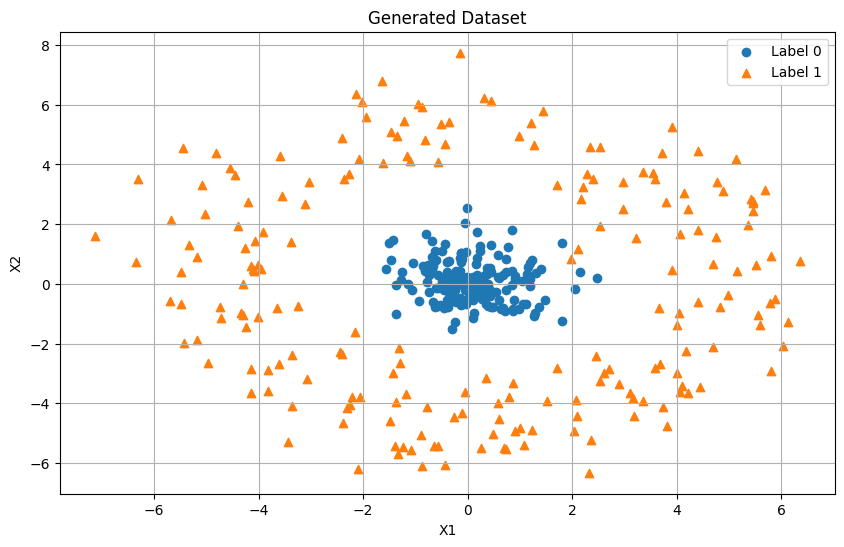

In [19]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(2026)
torch.manual_seed(2026)

# Number of data points per class
n_samples_per_class = 200

# Generate label 0 data
### START CODE HERE ###
r_label0 =
t_label0 =
x1_label0 =
x2_label0 =

# Generate label 1 data
r_label1 =
t_label1 =
x1_label1 =
x2_label1 =

### END CODE HERE ###

# Plot the dataset
plt.figure(figsize=(10, 6))
plt.scatter(x1_label0, x2_label0, label='Label 0')
plt.scatter(x1_label1, x2_label1, label='Label 1', marker='^')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Generated Dataset')
plt.legend()
plt.grid(True)
plt.show()

**Task (2.5 pts)**: create a `torch.Dataset` for your generated `x`s and `y`s data and labels.

(400, 2)
(400, 1)


**Expected Output**:

<table style="width:40%">
    <tr>
       <td><b>x.shape</b></td>
       <td> (400, 2)<br>
    </tr>
    <tr>
       <td><b>y.shape</b></td>
       <td>(400, 1)</td>
    </tr>
</table>


**Task (2.5 pts)**: Split your data into `70/15/15%` `train/val/test` sets and initialise the `DataLoader`.

In [21]:
### START CODE HERE ###


### END CODE HERE ###

# Print the sizes of each split to verify
print(f'Training size: {len(train)}')
print(f'Validation size: {len(val)}')
print(f'Test size: {len(test)}')

### START CODE HERE ###
train_data =
val_data =
### END CODE HERE ###


Training size: 280
Validation size: 60
Test size: 60


**Expected Output**:

<table style="width:40%">
    <tr>
       <td><b>Training size</b></td>
       <td> 280<br>
    </tr>
    <tr>
       <td><b>Validation size</b></td>
       <td>60</td>
    </tr>
    <tr>
       <td><b>Test size</b></td>
       <td>60</td>
    </tr>
</table>

**Task (2 pts)**: Create a simple MLP classifier with:
- 1 hidden layers
- ≤30 hidden nodes
- ReLU activation of the hidden layer.

Select your hyperparameters (eg., learning rate, batch size, etc.) to maximize your accuracy, as well as an appropriate loss function and output layer activation for the task.

(_hint_: use `nn.Linear`)

In [22]:
import torch.nn as nn

### START CODE HERE ###

### END CODE HERE ###

In [23]:
hidden_size = 10
model = Classifier(input_size=2, hidden_size=hidden_size)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

**Task (8 pts)** Write the training loop and plot your validation accuracies across time (x-axis is either epochs or steps) in a single figure.

1	batch-loss: 0.6540	batch-acc: 0.4893	val-loss: 0.6498	val-acc: 0.4833
2	batch-loss: 0.6427	batch-acc: 0.4929	val-loss: 0.6398	val-acc: 0.4833
3	batch-loss: 0.6317	batch-acc: 0.4929	val-loss: 0.6303	val-acc: 0.4833
4	batch-loss: 0.6215	batch-acc: 0.4929	val-loss: 0.6213	val-acc: 0.4833
5	batch-loss: 0.6116	batch-acc: 0.4929	val-loss: 0.6127	val-acc: 0.4833
6	batch-loss: 0.6023	batch-acc: 0.4929	val-loss: 0.6044	val-acc: 0.4833
7	batch-loss: 0.5935	batch-acc: 0.4929	val-loss: 0.5963	val-acc: 0.4833
8	batch-loss: 0.5848	batch-acc: 0.4929	val-loss: 0.5884	val-acc: 0.4833
9	batch-loss: 0.5765	batch-acc: 0.4929	val-loss: 0.5804	val-acc: 0.4833
10	batch-loss: 0.5683	batch-acc: 0.4929	val-loss: 0.5726	val-acc: 0.4833
11	batch-loss: 0.5606	batch-acc: 0.4929	val-loss: 0.5650	val-acc: 0.5000
12	batch-loss: 0.5527	batch-acc: 0.5036	val-loss: 0.5574	val-acc: 0.5333
13	batch-loss: 0.5451	batch-acc: 0.5179	val-loss: 0.5499	val-acc: 0.5500
14	batch-loss: 0.5375	batch-acc: 0.5357	val-loss: 0.5425	val

30	batch-loss: 0.4243	batch-acc: 0.8857	val-loss: 0.4281	val-acc: 0.8833


31	batch-loss: 0.4176	batch-acc: 0.8893	val-loss: 0.4212	val-acc: 0.8833
32	batch-loss: 0.4108	batch-acc: 0.8893	val-loss: 0.4144	val-acc: 0.9000
33	batch-loss: 0.4041	batch-acc: 0.9000	val-loss: 0.4078	val-acc: 0.9000
34	batch-loss: 0.3975	batch-acc: 0.9107	val-loss: 0.4011	val-acc: 0.9000
35	batch-loss: 0.3910	batch-acc: 0.9143	val-loss: 0.3946	val-acc: 0.9000


36	batch-loss: 0.3844	batch-acc: 0.9179	val-loss: 0.3881	val-acc: 0.9167
37	batch-loss: 0.3781	batch-acc: 0.9321	val-loss: 0.3818	val-acc: 0.9167
38	batch-loss: 0.3718	batch-acc: 0.9321	val-loss: 0.3754	val-acc: 0.9167
39	batch-loss: 0.3656	batch-acc: 0.9357	val-loss: 0.3692	val-acc: 0.9333
40	batch-loss: 0.3593	batch-acc: 0.9429	val-loss: 0.3632	val-acc: 0.9333
41	batch-loss: 0.3534	batch-acc: 0.9464	val-loss: 0.3569	val-acc: 0.9333
42	batch-loss: 0.3474	batch-acc: 0.9464	val-loss: 0.3510	val-acc: 0.9333
43	batch-loss: 0.3414	batch-acc: 0.9464	val-loss: 0.3452	val-acc: 0.9333
44	batch-loss: 0.3357	batch-acc: 0.9500	val-loss: 0.3392	val-acc: 0.9333
45	batch-loss: 0.3299	batch-acc: 0.9571	val-loss: 0.3335	val-acc: 0.9333
46	batch-loss: 0.3242	batch-acc: 0.9643	val-loss: 0.3278	val-acc: 0.9333
47	batch-loss: 0.3188	batch-acc: 0.9679	val-loss: 0.3221	val-acc: 0.9667
48	batch-loss: 0.3132	batch-acc: 0.9679	val-loss: 0.3169	val-acc: 0.9667
49	batch-loss: 0.3078	batch-acc: 0.9679	val-loss: 0

67	batch-loss: 0.2243	batch-acc: 0.9857	val-loss: 0.2280	val-acc: 0.9667


68	batch-loss: 0.2203	batch-acc: 0.9857	val-loss: 0.2241	val-acc: 0.9667
69	batch-loss: 0.2165	batch-acc: 0.9857	val-loss: 0.2203	val-acc: 0.9667
70	batch-loss: 0.2128	batch-acc: 0.9893	val-loss: 0.2165	val-acc: 0.9667
71	batch-loss: 0.2092	batch-acc: 0.9893	val-loss: 0.2127	val-acc: 0.9667
72	batch-loss: 0.2055	batch-acc: 0.9893	val-loss: 0.2091	val-acc: 0.9667


73	batch-loss: 0.2019	batch-acc: 0.9893	val-loss: 0.2057	val-acc: 0.9667
74	batch-loss: 0.1985	batch-acc: 0.9893	val-loss: 0.2020	val-acc: 0.9667
75	batch-loss: 0.1951	batch-acc: 0.9893	val-loss: 0.1986	val-acc: 0.9667
76	batch-loss: 0.1918	batch-acc: 0.9893	val-loss: 0.1952	val-acc: 0.9667
77	batch-loss: 0.1885	batch-acc: 0.9893	val-loss: 0.1921	val-acc: 0.9667
78	batch-loss: 0.1853	batch-acc: 0.9893	val-loss: 0.1890	val-acc: 0.9667
79	batch-loss: 0.1822	batch-acc: 0.9929	val-loss: 0.1857	val-acc: 0.9667
80	batch-loss: 0.1791	batch-acc: 0.9929	val-loss: 0.1826	val-acc: 0.9667
81	batch-loss: 0.1762	batch-acc: 0.9929	val-loss: 0.1794	val-acc: 0.9833
82	batch-loss: 0.1732	batch-acc: 0.9929	val-loss: 0.1765	val-acc: 0.9833
83	batch-loss: 0.1704	batch-acc: 0.9929	val-loss: 0.1736	val-acc: 0.9833
84	batch-loss: 0.1675	batch-acc: 0.9929	val-loss: 0.1707	val-acc: 0.9833
85	batch-loss: 0.1648	batch-acc: 0.9929	val-loss: 0.1680	val-acc: 0.9833
86	batch-loss: 0.1621	batch-acc: 0.9929	val-loss: 0

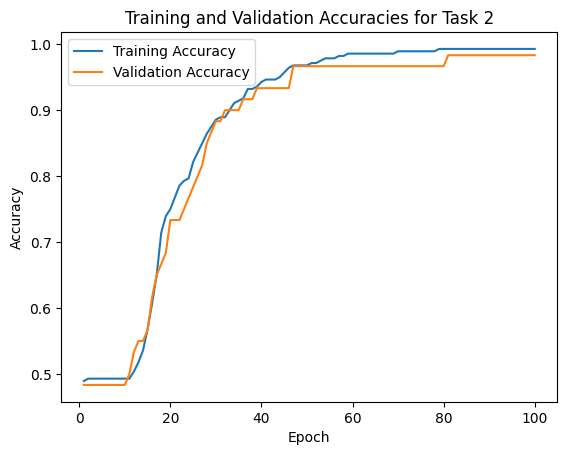

In [24]:
# Lists to store training and validation accuracies
train_accuracies = []
valid_accuracies = []
num_epochs = 100

for epoch in range(1, num_epochs+1):
    # Training loop

    ### START CODE HERE ###


    ### END CODE HERE ###


    # Validation loop

    ### START CODE HERE ###


    ### END CODE HERE ###


    print("%d\tbatch-loss: %.4f\tbatch-acc: %.4f\tval-loss: %.4f\tval-acc: %.4f"%(
        epoch, train_loss, train_acc, val_loss, val_acc))

# Plotting
epochs = range(1, num_epochs + 1)
plt.plot(epochs, train_accuracies, label='Training Accuracy')
plt.plot(epochs, valid_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracies for Task 2')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Task (10 pts)**: Plot your test data and overlay `ReLU` activation boundary lines:
- Plot the lines dividing active and inactive regions for the hiden layer's neurons.
- _NB_. We expect _n_ lines where _n_ is the number of nodes in your hidden layer.
- You activation function is `ReLU` so the dicision boundary is the *line* that divides the positivite and zero labels after `ReLU` (ie. $relu(x) > 0$ is activate, otherwise inactive)

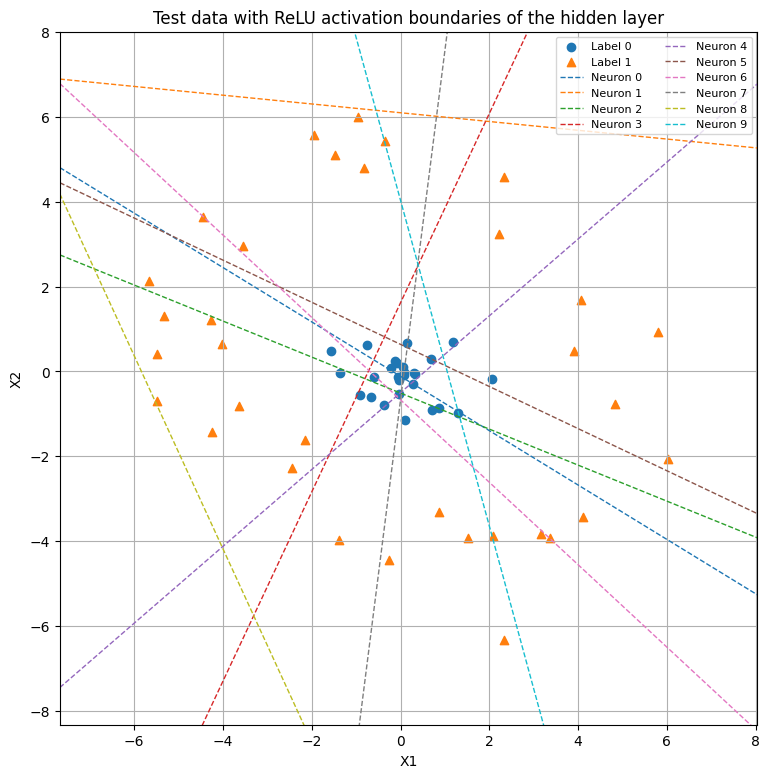

In [25]:
### START CODE HERE ###


### END CODE HERE ###